# Ejercicio Práctico Clase 3
Asignatura: Diseño de Procesos ETL en Data Science · MCDA-A

**Integrantes:**

1. Wilson Paredes
2. Gisell Poveda
3. Henry Perez

In [5]:
# Importacion de librerias.
import sqlite3
import pandas as pd
import hashlib
import requests
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from datetime import datetime

print("✅ Librerías cargadas exitosamente.")

✅ Librerías cargadas exitosamente.


## 1. Fase de Despliegue Físico (Arquitectura de Base de Datos)

Su solución deberá crear una base de datos nueva llamada **electroworld.db**. Las tablas de la base de datos deben reflejar el modelado que usted propuso en la Semana 1, además de una tabla específica para el catálogo de competidores/proveedores de la Semana 2.

In [6]:
def crear_base_de_datos_optimizada():
    # 1. Conexión a la base de datos central
    conn = sqlite3.connect('electroworld.db')
    cursor = conn.cursor()

    print("Creando arquitectura de alto rendimiento (Esquema Estrella) para ElectroWorld...")

    # DimCustomer: Consolidada para visión 360 (customer_unique_id como clave de negocio)
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DimCustomer (
            customer_unique_id       TEXT PRIMARY KEY,
            customer_zip_code_prefix TEXT,
            customer_city            TEXT,
            customer_state           TEXT
        )
    ''')

    # DimProduct: Incluye la traducción de categorías para Marketing
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DimProduct (
            product_id                    TEXT PRIMARY KEY,
            product_category_name_english TEXT,
            product_weight_g              REAL,
            product_length_cm             REAL,
            product_height_cm             REAL,
            product_width_cm              REAL
        )
    ''')

    # DimReview: Dimensión de satisfacción del cliente
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DimReview (
            review_id              TEXT PRIMARY KEY,
            review_score           INTEGER,
            review_comment_title   TEXT,
            review_comment_message TEXT,
            review_creation_date   DATETIME
        )
    ''')

    # DimSeller: Dimensión de vendedores
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DimSeller (
            seller_id              TEXT PRIMARY KEY,
            seller_zip_code_prefix TEXT,
            seller_city            TEXT,
            seller_state           TEXT
        )
    ''')

    # DimTime: Dimensión de tiempo con granularidad diaria
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DimTime (
            time_id     TEXT PRIMARY KEY,
            date        DATE,
            year        INTEGER,
            month       INTEGER,
            day         INTEGER,
            day_of_week INTEGER,
            is_weekend  INTEGER,
            hour        INTEGER
        )
    ''')

    # FactSales: Tabla de hechos central — transacciones de ítems de pedido
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS FactSales (
            order_id       TEXT,
            order_item_id  INTEGER,
            DimCustomer_id TEXT,
            DimProduct_id  TEXT,
            DimSeller_id   TEXT,
            DimReview_id   TEXT,
            DimTime_id     TEXT,
            price          REAL,
            freight_value  REAL,
            payment_value  REAL,
            PRIMARY KEY (order_id, order_item_id),
            FOREIGN KEY (DimCustomer_id) REFERENCES DimCustomer (customer_unique_id),
            FOREIGN KEY (DimProduct_id)  REFERENCES DimProduct  (product_id),
            FOREIGN KEY (DimSeller_id)   REFERENCES DimSeller   (seller_id),
            FOREIGN KEY (DimReview_id)   REFERENCES DimReview   (review_id),
            FOREIGN KEY (DimTime_id)     REFERENCES DimTime     (time_id)
        )
    ''')

    # competitor_catalog: Datos externos del scraping de la Semana 2
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS competitor_catalog (
            id_competitor   INTEGER PRIMARY KEY AUTOINCREMENT,
            product_name    TEXT,
            price           REAL,
            rating          REAL,
            review_count    INTEGER,
            extraction_date DATETIME
        )
    ''')

    conn.commit()
    print("Fase 1 Completada: Esquema Estrella desplegado exitosamente.")
    conn.close()

# Ejecutar el despliegue
crear_base_de_datos_optimizada()

Creando arquitectura de alto rendimiento (Esquema Estrella) para ElectroWorld...
Fase 1 Completada: Esquema Estrella desplegado exitosamente.


## 2. Fase de Ciberseguridad y Calidad

Deberá crear al menos una regla lógica que impida la entrada de datos corruptos (ej. verificar que no haya precios negativos o fechas inválidas), seguido de un enmascaramiento, en donde seleccionará un campo sensible de los datasets (puede ser el ID del cliente de Olist o el costo del proveedor) y aplicará un proceso para anonimizarlo.

In [7]:
def aplicar_reglas_calidad(df_ventas):
    """
    Regla de Calidad 1: Verifica que no existan precios o valores de pago negativos.
    Impacto: Evita errores financieros en el cálculo del LTV del CRM.
    """
    registros_iniciales = len(df_ventas)
    df_ventas = df_ventas[df_ventas['price'] > 0]
    df_ventas = df_ventas[df_ventas['payment_value'] >= 0]
    registros_finales = len(df_ventas)
    print(f"Calidad 1: Se eliminaron {registros_iniciales - registros_finales} registros por valores inválidos.")
    return df_ventas


def validar_fechas(df, columna):
    """
    Regla de Calidad 2: Verifica que las columnas de fecha no contengan valores nulos
    o mal formateados tras la conversión a datetime.
    Impacto: Evita que registros con fechas inválidas rompan la construcción de DimTime
    y la segmentación temporal de campañas de marketing.
    """
    registros_iniciales = len(df)
    df[columna] = pd.to_datetime(df[columna], errors='coerce')
    df = df.dropna(subset=[columna])
    registros_finales = len(df)
    print(f"Calidad 2: Se eliminaron {registros_iniciales - registros_finales} registros con fechas inválidas en '{columna}'.")
    return df


def enmascarar_datos_sensibles(customer_id_text):
    """
    Ciberseguridad: Aplica un hash SHA-256 al ID del cliente.
    Impacto: Anonimiza al usuario. Si la base de datos se filtra, no se podrá
    recuperar el ID original, pero el CRM aún puede usar el hash como llave única.
    """
    if pd.isna(customer_id_text):
        return None
    hash_object = hashlib.sha256(customer_id_text.encode())
    return hash_object.hexdigest()


print("Configurando políticas de Ciberseguridad y Calidad...")
print("Fase 2: Políticas listas para ser aplicadas en la carga.")

Configurando políticas de Ciberseguridad y Calidad...
Fase 2: Políticas listas para ser aplicadas en la carga.


## 3. Fase de Carga e Integración (Load)

Su código debe insertar la información dentro de las tablas SQL creadas en el Paso 1. Deberá cargar todos los datos de Olist respetando su modelo de dimensiones y hechos, y el DataFrame maestro del catálogo externo (competencia y proveedor) que consolidó en la Semana 2.

In [8]:
# Pipeline de competencia — re-ejecución del catálogo externo (Semana 2)
def obtener_catalogo_competencia():
    """
    Re-ejecuta el pipeline ETL de la Semana 2:
      - Scraping del sitio del competidor (webscraper.io)
      - Consumo de la API FakeStore (nuevo proveedor)
      - Transformación y consolidación en un catálogo maestro
    Retorna el DataFrame consolidado listo para cargar en competitor_catalog.
    """
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

    # Fuente 1: Web Scraping del competidor
    datos_web = []
    try:
        url_web = "https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops"
        response = requests.get(url_web, headers=headers, timeout=10)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        for p in soup.find_all('div', class_='thumbnail'):
            try:
                nombre      = p.find('a', class_='title').text.strip()
                precio_num  = float(p.find('h4', class_='price').text.strip().replace('$', '').replace(',', ''))
                rev_num     = int(p.find('p', class_='review-count').text.strip().split()[0])
                rating      = int(p.find('p', {'data-rating': True})['data-rating'])
                descripcion = p.find('p', class_='description').text.strip()
                datos_web.append({'Nombre': nombre, 'Precio': precio_num, 'Descripción': descripcion,
                                   'Reviews': rev_num, 'Rating': rating, 'Origen': 'Web_Competidor'})
            except Exception:
                continue
        print(f"  Scraping completado: {len(datos_web)} productos extraídos del competidor.")
    except Exception as e:
        print(f"  Advertencia scraping: {e}")

    df_web = pd.DataFrame(datos_web)

    # Fuente 2: API FakeStore (nuevo proveedor)
    datos_api = []
    try:
        url_api = "https://fakestoreapi.com/products/category/electronics"
        response_api = requests.get(url_api, timeout=10)
        response_api.raise_for_status()
        for item in response_api.json():
            try:
                datos_api.append({
                    'Nombre':      item.get('title', 'Sin nombre'),
                    'Precio':      float(item.get('price', 0)),
                    'Descripción': item.get('description', ''),
                    'Reviews':     int(item.get('rating', {}).get('count', 0)),
                    'Rating':      round(float(item.get('rating', {}).get('rate', 0))),
                    'Origen':      'API_Nuevo_Proveedor'
                })
            except Exception:
                continue
        print(f"  API completada: {len(datos_api)} productos extraídos del proveedor.")
    except Exception as e:
        print(f"  Advertencia API: {e}")

    df_api = pd.DataFrame(datos_api)

    # Transformación y consolidación
    fuentes = [df for df in [df_web, df_api] if not df.empty]
    if not fuentes:
        print("  No se pudo obtener datos de ninguna fuente externa.")
        return pd.DataFrame()

    catalogo = pd.concat(fuentes, ignore_index=True)
    catalogo['Precio']      = pd.to_numeric(catalogo['Precio'], errors='coerce')
    catalogo['Reviews']     = pd.to_numeric(catalogo['Reviews'], errors='coerce').fillna(0).astype(int)
    catalogo['Rating']      = pd.to_numeric(catalogo['Rating'],  errors='coerce').fillna(0).astype(int)
    catalogo['Nombre']      = catalogo['Nombre'].astype(str).str.strip()
    catalogo['Descripción'] = catalogo['Descripción'].astype(str).str.strip().replace('', 'Sin descripción disponible')
    mediana_precio          = catalogo['Precio'].median()
    catalogo['Precio']      = catalogo['Precio'].fillna(mediana_precio)
    catalogo = catalogo.drop_duplicates(subset=['Nombre', 'Precio'], keep='first').reset_index(drop=True)
    catalogo['Fecha_Ingesta'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f"  Catálogo maestro consolidado: {len(catalogo)} productos únicos.")
    return catalogo


def fase_3():
    def descargar_datos():
        archivos = [
            "olist_customers_dataset.csv", "olist_order_items_dataset.csv",
            "olist_order_payments_dataset.csv", "olist_order_reviews_dataset.csv",
            "olist_orders_dataset.csv", "olist_products_dataset.csv",
            "olist_sellers_dataset.csv", "product_category_name_translation.csv"
        ]
        ruta_base = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
        datasets = {}
        for archivo in archivos:
            ruta_full = os.path.join(ruta_base, archivo)
            nombre_df = archivo.replace('olist_', '').replace('_dataset', '').replace('.csv', '')
            datasets[nombre_df] = pd.read_csv(ruta_full, encoding='latin1')
        return datasets

    data = descargar_datos()
    conn = sqlite3.connect('electroworld.db')

    try:
        print("Iniciando depuración de columnas y transformaciones...")

        # 1. Limpieza de nombres de columnas
        for df_name in data:
            data[df_name].columns = data[df_name].columns.str.strip()

        # 2. Ciberseguridad: Enmascarar customer_unique_id
        data['customers']['customer_unique_id'] = (
            data['customers']['customer_unique_id'].apply(enmascarar_datos_sensibles)
        )

        # 3. Merge de productos con traducción de categorías
        df_prod  = data['products']
        df_trans = data['product_category_name_translation']
        col_cat  = 'product_category_name'
        if col_cat in df_prod.columns and col_cat in df_trans.columns:
            df_products_clean = pd.merge(df_prod, df_trans, on=col_cat, how='left')
        else:
            df_products_clean = df_prod.copy()
            df_products_clean['product_category_name_english'] = df_prod[col_cat]

        # 4. Construcción de DimTime a partir de order_purchase_timestamp
        df_orders_ts = data['orders'][['order_id', 'order_purchase_timestamp']].copy()
        df_orders_ts['order_purchase_timestamp'] = pd.to_datetime(
            df_orders_ts['order_purchase_timestamp'], errors='coerce'
        )
        df_time = df_orders_ts['order_purchase_timestamp'].dropna().dt.normalize().drop_duplicates()
        df_dimtime = pd.DataFrame({
            'time_id':     df_time.dt.strftime('%Y%m%d'),
            'date':        df_time.dt.date.astype(str),
            'year':        df_time.dt.year,
            'month':       df_time.dt.month,
            'day':         df_time.dt.day,
            'day_of_week': df_time.dt.dayofweek,
            'is_weekend':  (df_time.dt.dayofweek >= 5).astype(int),
            'hour':        df_time.dt.hour
        }).drop_duplicates('time_id').reset_index(drop=True)

        # 5. Construcción de FactSales
        df_reviews_ord = data['order_reviews'][['order_id', 'review_id']].drop_duplicates('order_id')

        df_sales = pd.merge(data['order_items'], data['order_payments'], on='order_id', how='inner')
        df_sales = pd.merge(
            df_sales,
            data['orders'][['order_id', 'customer_id', 'order_purchase_timestamp']],
            on='order_id', how='inner'
        )
        df_sales = pd.merge(
            df_sales,
            data['customers'][['customer_id', 'customer_unique_id']],
            on='customer_id', how='inner'
        )
        df_sales = pd.merge(df_sales, df_reviews_ord, on='order_id', how='left')

        df_sales['order_purchase_timestamp'] = pd.to_datetime(
            df_sales['order_purchase_timestamp'], errors='coerce'
        )
        df_sales['DimTime_id'] = df_sales['order_purchase_timestamp'].dt.strftime('%Y%m%d')

        # 6. Reglas de calidad
        df_sales = aplicar_reglas_calidad(df_sales)
        df_sales = validar_fechas(df_sales, 'order_purchase_timestamp')

        # Carga a SQL
        print("Insertando datos en electroworld.db...")

        data['customers'][['customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']] \
            .drop_duplicates('customer_unique_id') \
            .to_sql('DimCustomer', conn, if_exists='replace', index=False)

        cols_prod = ['product_id', 'product_category_name_english',
                     'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
        df_products_clean[[c for c in cols_prod if c in df_products_clean.columns]] \
            .to_sql('DimProduct', conn, if_exists='replace', index=False)

        data['sellers'][['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']] \
            .to_sql('DimSeller', conn, if_exists='replace', index=False)

        data['order_reviews'][['review_id', 'review_score', 'review_comment_title',
                               'review_comment_message', 'review_creation_date']] \
            .drop_duplicates('review_id') \
            .to_sql('DimReview', conn, if_exists='replace', index=False)

        df_dimtime.to_sql('DimTime', conn, if_exists='replace', index=False)

        df_sales.rename(columns={
            'customer_unique_id': 'DimCustomer_id',
            'product_id':         'DimProduct_id',
            'seller_id':          'DimSeller_id',
            'review_id':          'DimReview_id'
        }, inplace=True)

        cols_fact = ['order_id', 'order_item_id', 'DimCustomer_id', 'DimProduct_id',
                     'DimSeller_id', 'DimReview_id', 'DimTime_id',
                     'price', 'freight_value', 'payment_value']
        df_sales[[c for c in cols_fact if c in df_sales.columns]] \
            .to_sql('FactSales', conn, if_exists='replace', index=False)

        # Cargar catálogo externo de la Semana 2
        print("\nObteniendo catálogo de competencia (Semana 2)...")
        df_competencia = obtener_catalogo_competencia()

        if not df_competencia.empty:
            df_comp_sql = pd.DataFrame({
                'product_name':    df_competencia['Nombre'],
                'price':           df_competencia['Precio'],
                'rating':          df_competencia['Rating'],
                'review_count':    df_competencia['Reviews'],
                'extraction_date': df_competencia['Fecha_Ingesta']
            })
            df_comp_sql.to_sql('competitor_catalog', conn, if_exists='replace', index=False)
            print(f"  competitor_catalog cargada: {len(df_comp_sql)} registros.")

        print("\nFase 3 Completada exitosamente.")

    except Exception as e:
        print(f"Error crítico: {e}")
        import traceback; traceback.print_exc()
    finally:
        conn.close()

fase_3()

Iniciando depuración de columnas y transformaciones...
Calidad 1: Se eliminaron 0 registros por valores inválidos.
Calidad 2: Se eliminaron 0 registros con fechas inválidas en 'order_purchase_timestamp'.
Insertando datos en electroworld.db...

Obteniendo catálogo de competencia (Semana 2)...
  Scraping completado: 117 productos extraídos del competidor.
  API completada: 6 productos extraídos del proveedor.
  Catálogo maestro consolidado: 120 productos únicos.
  competitor_catalog cargada: 120 registros.

Fase 3 Completada exitosamente.


## 4. Resultado de Negocio

Para demostrar a la directiva que la arquitectura funciona y los datos están relacionados, su solución debe ejecutar una consulta SQL (SELECT) directamente desde Python que una (JOIN) al menos dos tablas de su modelo (ej. Ventas con Productos) e imprima los primeros resultados en pantalla, demostrando que el sistema está listo para ser conectado al CRM.

      REPORTE EJECUTIVO: RESULTADO DE NEGOCIO (CRM)         

── Muestra JOIN FactSales × DimProduct × DimCustomer (Olist) ──
                        ID_Orden             Categoria  Precio_Item  Flete  Valor_Pago                Ciudad                                                     Cliente_Hash
00010242fe8c5a6d1ba2dd792cb16214            cool_stuff        58.90  13.29       72.19 campos dos goytacazes cb0272153a203d3a5540f1a06fc9f1231846c14925ed05d3cc38cda935124edd
00018f77f2f0320c557190d7a144bdd3              pet_shop       239.90  19.93      259.83       santa fe do sul 5b176b440dabe249b48ae9fd0f4483f3457ca3ace38c49d77384ce4a41ff1068
000229ec398224ef6ca0657da4fc703e      moveis_decoracao       199.00  17.87      216.87         para de minas ce699d575b5c685ce3f045c311504e85aef91e4cb30109d068facbe2269c54bb
00024acbcdf0a6daa1e931b038114c75            perfumaria        12.99  12.79       25.78               atibaia 65ac5ff653a23179ecfba23809473b0f1d373ec5eb71b9e4921d471c5b9d8876
0004

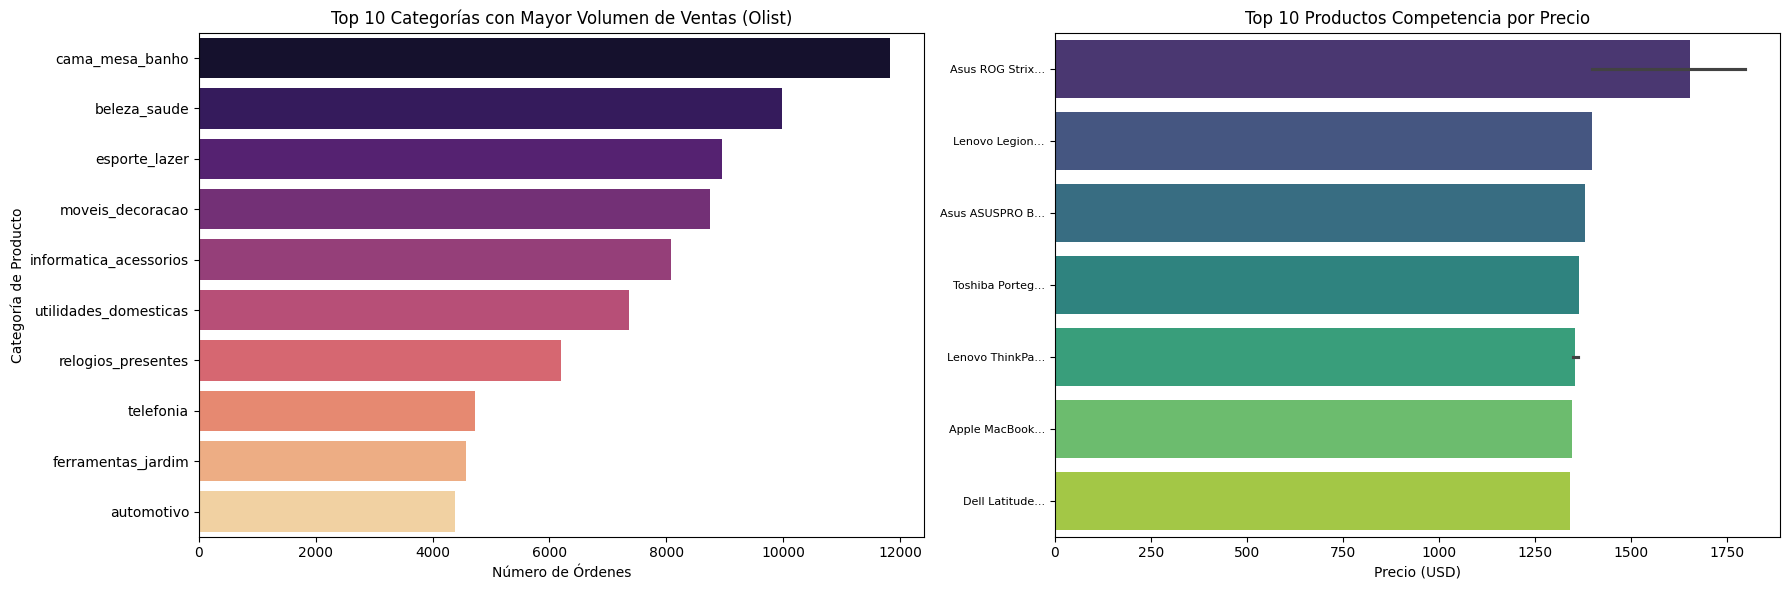


Verificación exitosa: El sistema SQL responde correctamente y los datos están relacionados.


In [9]:
def fase_4():
    conn = sqlite3.connect('electroworld.db')

    print("============================================================")
    print("      REPORTE EJECUTIVO: RESULTADO DE NEGOCIO (CRM)         ")
    print("============================================================\n")

    query_crm = """
    SELECT
        f.order_id                         AS ID_Orden,
        p.product_category_name_english    AS Categoria,
        f.price                            AS Precio_Item,
        f.freight_value                    AS Flete,
        f.payment_value                    AS Valor_Pago,
        c.customer_city                    AS Ciudad,
        f.DimCustomer_id                   AS Cliente_Hash
    FROM FactSales f
    JOIN DimProduct  p ON f.DimProduct_id  = p.product_id
    JOIN DimCustomer c ON f.DimCustomer_id = c.customer_unique_id
    LIMIT 10;
    """

    query_competencia = """
    SELECT
        product_name,
        price,
        rating,
        review_count,
        extraction_date
    FROM competitor_catalog
    ORDER BY price DESC
    LIMIT 15;
    """

    query_grafico = """
    SELECT
        p.product_category_name_english AS categoria,
        COUNT(f.order_id)               AS total_ventas
    FROM FactSales f
    JOIN DimProduct p ON f.DimProduct_id = p.product_id
    WHERE p.product_category_name_english IS NOT NULL
    GROUP BY categoria
    ORDER BY total_ventas DESC
    LIMIT 10;
    """

    try:
        df_crm      = pd.read_sql_query(query_crm, conn)
        df_comp     = pd.read_sql_query(query_competencia, conn)
        df_grafico  = pd.read_sql_query(query_grafico, conn)
        df_comp_top = df_comp.head(10)

        print("── Muestra JOIN FactSales × DimProduct × DimCustomer (Olist) ──")
        print(df_crm.to_string(index=False))

        print("\n── Catálogo de Competencia (competitor_catalog) ──")
        print(df_comp.to_string(index=False))

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        sns.barplot(x='total_ventas', y='categoria', data=df_grafico,
                    palette='magma', ax=axes[0], hue='categoria', legend=False)
        axes[0].set_title('Top 10 Categorías con Mayor Volumen de Ventas (Olist)', fontsize=12)
        axes[0].set_xlabel('Número de Órdenes')
        axes[0].set_ylabel('Categoría de Producto')

        sns.barplot(x='price', y='product_name', data=df_comp_top,
                    palette='viridis', ax=axes[1], hue='product_name', legend=False)
        axes[1].set_title('Top 10 Productos Competencia por Precio', fontsize=12)
        axes[1].set_xlabel('Precio (USD)')
        axes[1].set_ylabel('')
        axes[1].tick_params(axis='y', labelsize=8)

        plt.tight_layout()
        plt.show()

        print("\nVerificación exitosa: El sistema SQL responde correctamente y los datos están relacionados.")

    except Exception as e:
        print(f"Error al ejecutar el Resultado de Negocio: {e}")
        import traceback; traceback.print_exc()
    finally:
        conn.close()

fase_4()